AI-Powered Movie Recommendation System

In [60]:
!pip install faker

In [61]:
# Work with JSON files
import json

# Generate random values
import random

class Movie:
    # Constructor
    def __init__(self, title, genre, director, rating):
        # Movie attributes
        self.title = title
        self.genre = genre
        self.director = director
        self.rating = rating

    #convert object Movie into dictionary so later it can be stored in json
    def to_dict(self):
        return {
            "title": self.title,
            "genre": self.genre,
            "director": self.director,
            "rating": self.rating
        }


In [62]:
class User:
    # Constructor
    def __init__(self, name, age, preferences, watch_history=None):
        # User attributes
        self.name = name
        self.age = age
        self.preferences = preferences

        # Create empty watch history if none provided
        if watch_history is None:
            self.watch_history = []
        else:
            self.watch_history = watch_history


    #convert object user into dictionary so later it can be stored in json
    def to_dict(self):
        return {
            "name": self.name,
            "age": self.age,
            "preferences": self.preferences,
            "watch_history": self.watch_history
        }

In [63]:
# Generate fake users
from faker import Faker

# Create Faker object
fake = Faker()

# List of movie genres
genres = [
    "Action",
    "Drama",
    "Comedy",
    "Sci-Fi",
    "Thriller",
    "Horror",
    "Romance"
]

# Function to generate fake users
def generate_users(count): #function

    # Empty list for users
    users = []

    # Create users in loop
    for _ in range(count):

        # Generate random user
        user = User(
            fake.name(),
            random.randint(18, 60),
            random.sample(genres, 2)
        )

        # Add user to list
        users.append(user)

    return users

In [64]:
# Generate 1000 users
users = generate_users(1000)

# Print first 5 users
for user in users[:5]:

    print(user.name)
    print(user.age)
    print(user.preferences)
    print("------")


Elizabeth Castro
52
['Romance', 'Horror']
------
Donna Stokes
29
['Drama', 'Sci-Fi']
------
Timothy Munoz
33
['Thriller', 'Drama']
------
Karen West
20
['Action', 'Sci-Fi']
------
Michael Smith
40
['Action', 'Comedy']
------


In [65]:
# Movie titles for fetching data from OMDb API
movie_titles = [
    "Interstellar",
    "Inception",
    "The Dark Knight",
    "Titanic",
    "The Notebook",
    "Avengers: Endgame",
    "Get Out",
    "Parasite",
    "Superbad",
    "The Conjuring",
    "John Wick",
    "La La Land",
    "Joker",
    "Dune",
    "Deadpool"
]

In [66]:
import requests
# API key
api_key = "80b26e3a"


# Function to get movie information from OMDb
def get_movie_info(title):

    # Build request URL
    url = f"https://www.omdbapi.com/?apikey={api_key}&t={title}"

    # Send HTTP request to API
    response = requests.get(url)

    # Convert JSON response to Python dictionary
    data = response.json()

    return data

In [67]:
#check for one movie
movie_data = get_movie_info("Interstellar")

# Display selected movie information

print("Title:", movie_data["Title"])
print("Year:", movie_data["Year"])
print("Genre:", movie_data["Genre"])
print("Director:", movie_data["Director"])
print("IMDb Rating:", movie_data["imdbRating"])

Title: Interstellar
Year: 2014
Genre: Adventure, Drama, Sci-Fi
Director: Christopher Nolan
IMDb Rating: 8.7


In [68]:
# Build movie dataset from OMDb API
def build_movie_dataset(movie_titles):

    movies = []

    for title in movie_titles:

        # Get movie data from API
        data = get_movie_info(title)

        # Skip movie if API request failed
        if data is None:
            continue

        # Create Movie object
        movie = Movie(
            data["Title"],
            data["Genre"],
            data["Director"],
            float(data["imdbRating"]) #text converted to fload for further sorting
        )

        movies.append(movie)

    return movies

In [69]:
movies = build_movie_dataset(movie_titles)

In [70]:
print(len(movies))

print(movies[0].title)
print(movies[0].rating)

15
Interstellar
8.7


In [71]:
##prepare movies for storing in json (convert movie objects to dicttionaries)
movies_data = [movie.to_dict() for movie in movies]

# Save movies to JSON
with open("movies.json", "w") as file:

    json.dump(
        movies_data,
        file,
        indent=4
    )

In [72]:
# Function to generate watch history
def generate_watch_history(users, movies):

    # Loop through all users
    for user in users:

        # Random number of watched movies
        watched_movies = random.sample(
            movies,
            random.randint(3, 8)
        )

        # Add movies to watch history
        for movie in watched_movies:

            # Create watch history record
            history_entry = {
                "movie": movie.title,
                "genre": movie.genre,
                "director": movie.director,
                "user_rating": random.randint(1, 5),
                "watch_date": str(
                  fake.date_between(
                    start_date="-30d",
                    end_date="today"
                 )
)
            }

            # Add record to user history
            user.watch_history.append(history_entry)

In [73]:
# Generate watch history (as list of dictionaries)
generate_watch_history(users, movies)
print(users[0].watch_history)

[{'movie': 'Dune', 'genre': 'Action, Adventure, Sci-Fi', 'director': 'David Lynch', 'user_rating': 4, 'watch_date': '2026-05-31'}, {'movie': 'The Conjuring', 'genre': 'Horror, Mystery, Thriller', 'director': 'James Wan', 'user_rating': 1, 'watch_date': '2026-05-25'}, {'movie': 'Deadpool', 'genre': 'Action, Comedy, Sci-Fi', 'director': 'Tim Miller', 'user_rating': 3, 'watch_date': '2026-06-01'}]


In [74]:
# Recommendation by genre (movies of the genre preferred by a user, having highest rating) engine class
class RecommendationEngine:

    # Constructor
    def __init__(self, movies):

        # Store movie dataset
        self.movies = movies

    # Generate recommendations
    def recommend_movies(self, user):

        # List of watched movie titles
        watched_titles = [
            history_entry["movie"]
            for history_entry in user.watch_history
        ]

        # Filter matching movies
        recommendations = [

            movie for movie in self.movies

            # Match user preferences
            if any(
                genre in user.preferences
                for genre in movie.genre.split(", ")
            )

            # Exclude watched movies
            and movie.title not in watched_titles
        ]

        # Sort by movie rating
        recommendations.sort(
            key=lambda movie: movie.rating, #lambda - anonymous function
            reverse=True #highest rated first
        )

        return recommendations

In [75]:
#create recommendation engine
engine = RecommendationEngine(movies)
#generate 5 recommendations for the 1st user in the list
recommendations = engine.recommend_movies(users[0])

for movie in recommendations[:5]: #slicing

    print(movie.title)
    print(movie.genre)
    print(movie.rating)
    print("------")



Titanic
Drama, Romance
8.0
------
The Notebook
Drama, Romance
7.8
------
Get Out
Horror, Mystery, Thriller
7.8
------


In [76]:
def explain_recommendation(user, movie):

    # Find watched movies of the same genre
    similar_movies = [
        entry["movie"]
        for entry in user.watch_history
        if movie.genre in entry["genre"]
    ]

    if len(similar_movies) > 0:
        return (
            f"Since you liked {similar_movies[0]}, "
            f"you might enjoy {movie.title}"
        )

    return f"We recommend {movie.title}"

In [77]:
user = users[0]

recommendations = engine.recommend_movies(user)

for movie in recommendations[:5]:

    print(explain_recommendation(user, movie))

    print("Genre:", movie.genre)
    print("Rating:", movie.rating)

    print("-----------")

We recommend Titanic
Genre: Drama, Romance
Rating: 8.0
-----------
We recommend The Notebook
Genre: Drama, Romance
Rating: 7.8
-----------
Since you liked The Conjuring, you might enjoy Get Out
Genre: Horror, Mystery, Thriller
Rating: 7.8
-----------


In [78]:
#check
print(users[0].preferences)

['Romance', 'Horror']


In [79]:
#check dict structure for the 1st user
print(users[0].to_dict())

{'name': 'Elizabeth Castro', 'age': 52, 'preferences': ['Romance', 'Horror'], 'watch_history': [{'movie': 'Dune', 'genre': 'Action, Adventure, Sci-Fi', 'director': 'David Lynch', 'user_rating': 4, 'watch_date': '2026-05-31'}, {'movie': 'The Conjuring', 'genre': 'Horror, Mystery, Thriller', 'director': 'James Wan', 'user_rating': 1, 'watch_date': '2026-05-25'}, {'movie': 'Deadpool', 'genre': 'Action, Comedy, Sci-Fi', 'director': 'Tim Miller', 'user_rating': 3, 'watch_date': '2026-06-01'}]}


In [80]:
#prepare users for storing in json (convert users objects to dicttionaries)
users_data = [user.to_dict() for user in users]

# Save (dump command) users to JSON
with open("users.json", "w") as file: #with open(...) - Python best practice: safely open file (w - write mode - create new file or re-write existing obe) and close it automatically

    json.dump(
        users_data,
        file,
        indent=4
    )

Next steps:

*   Data preprocessing and transformation with Pandas and NumPy
*   Statistical analysis
*   Data visualization
*   SciPy (pearsonr)
*   KMeans clustering












In [81]:
import pandas as pd

# Empty list for dataframe rows
rows = []

# Extract data from users
for user in users:

    for history_entry in user.watch_history:

        rows.append({
            "user_name": user.name,
            "movie": history_entry["movie"],
            "genre": history_entry["genre"],
            "user_rating": history_entry["user_rating"],
            "watch_date": history_entry["watch_date"]
        })

# Create dataframe
df = pd.DataFrame(rows)

print(df.head(10))

          user_name          movie                      genre  user_rating  \
0  Elizabeth Castro           Dune  Action, Adventure, Sci-Fi            4   
1  Elizabeth Castro  The Conjuring  Horror, Mystery, Thriller            1   
2  Elizabeth Castro       Deadpool     Action, Comedy, Sci-Fi            3   
3      Donna Stokes       Superbad                     Comedy            2   
4      Donna Stokes       Deadpool     Action, Comedy, Sci-Fi            5   
5      Donna Stokes      Inception  Action, Adventure, Sci-Fi            3   
6     Timothy Munoz          Joker     Crime, Drama, Thriller            1   
7     Timothy Munoz       Parasite            Drama, Thriller            4   
8     Timothy Munoz     La La Land       Comedy, Drama, Music            3   
9        Karen West  The Conjuring  Horror, Mystery, Thriller            5   

   watch_date  
0  2026-05-31  
1  2026-05-25  
2  2026-06-01  
3  2026-05-26  
4  2026-05-31  
5  2026-05-21  
6  2026-05-13  
7  2026-05-28

In [82]:
# Check dataframe shape
print(df.shape)

(5464, 5)


In [83]:
#check if we have dublicates
print(df.duplicated().sum())

0


In [84]:
#view what the dublicates are
df[df.duplicated(keep=False)]

,user_name,movie,genre,user_rating,watch_date


In [85]:
#delete duplicate
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [86]:
#check missing values
print(df.isnull().sum())

user_name      0
movie          0
genre          0
user_rating    0
watch_date     0
dtype: int64


In [87]:
#check data types
print(df.dtypes)

user_name      object
movie          object
genre          object
user_rating     int64
watch_date     object
dtype: object


In [88]:
#Plot the distribution of genres in a user's watch history
#create copy of the dataframe to process column Genre
df_genres = df.copy()

#split Genre to the list, so instead of "Action, Crime, Thriller" it became ["Action", "Crime", "Thriller"]
df_genres["genre"] = df_genres["genre"].str.split(", ")
print(df_genres.head())

          user_name          movie                        genre  user_rating  \
0  Elizabeth Castro           Dune  [Action, Adventure, Sci-Fi]            4   
1  Elizabeth Castro  The Conjuring  [Horror, Mystery, Thriller]            1   
2  Elizabeth Castro       Deadpool     [Action, Comedy, Sci-Fi]            3   
3      Donna Stokes       Superbad                     [Comedy]            2   
4      Donna Stokes       Deadpool     [Action, Comedy, Sci-Fi]            5   

   watch_date  
0  2026-05-31  
1  2026-05-25  
2  2026-06-01  
3  2026-05-26  
4  2026-05-31  


In [89]:
#convert list into rows
df_genres = df_genres.explode("genre")
print(df_genres.head(10))

          user_name          movie      genre  user_rating  watch_date
0  Elizabeth Castro           Dune     Action            4  2026-05-31
0  Elizabeth Castro           Dune  Adventure            4  2026-05-31
0  Elizabeth Castro           Dune     Sci-Fi            4  2026-05-31
1  Elizabeth Castro  The Conjuring     Horror            1  2026-05-25
1  Elizabeth Castro  The Conjuring    Mystery            1  2026-05-25
1  Elizabeth Castro  The Conjuring   Thriller            1  2026-05-25
2  Elizabeth Castro       Deadpool     Action            3  2026-06-01
2  Elizabeth Castro       Deadpool     Comedy            3  2026-06-01
2  Elizabeth Castro       Deadpool     Sci-Fi            3  2026-06-01
3      Donna Stokes       Superbad     Comedy            2  2026-05-26


In [90]:
# calculate genre frequency (shows genre popularity)
genre_counts = df_genres["genre"].value_counts()
print(genre_counts)

genre
Drama        2576
Action       2201
Thriller     1798
Sci-Fi       1792
Adventure    1428
Comedy       1108
Crime        1106
Romance       755
Mystery       692
Horror        692
Music         374
Name: count, dtype: int64


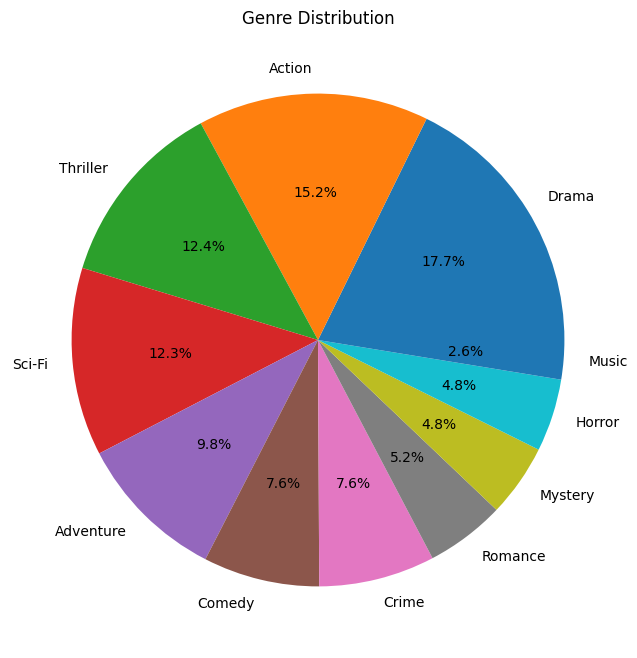

In [91]:
# pie chart
import matplotlib.pyplot as plt

# Create pie chart
plt.figure(figsize=(8, 8))

genre_counts.plot(
    kind="pie",
    autopct="%1.1f%%" #show % on the chart
)

plt.ylabel("")
plt.title("Genre Distribution")

plt.show()

Drama is the most common genre in the dataset (17.4%).
Action, Sci-Fi and Thriller are also highly represented.
Music is the least common genre (2.5%).

In [92]:
#Visualize the change in user ratings over time.
# make sure we have watch_date column
print(df.head())

          user_name          movie                      genre  user_rating  \
0  Elizabeth Castro           Dune  Action, Adventure, Sci-Fi            4   
1  Elizabeth Castro  The Conjuring  Horror, Mystery, Thriller            1   
2  Elizabeth Castro       Deadpool     Action, Comedy, Sci-Fi            3   
3      Donna Stokes       Superbad                     Comedy            2   
4      Donna Stokes       Deadpool     Action, Comedy, Sci-Fi            5   

   watch_date  
0  2026-05-31  
1  2026-05-25  
2  2026-06-01  
3  2026-05-26  
4  2026-05-31  


In [93]:
# Calculate average rating by date
daily_ratings = (
    df.groupby("watch_date")["user_rating"]
    .mean()
    .reset_index() #reset_index() converts watch_date to the column, because it became index after grouping
)

print(daily_ratings.head())

   watch_date  user_rating
0  2026-05-08     2.970297
1  2026-05-09     2.932292
2  2026-05-10     3.000000
3  2026-05-11     3.189189
4  2026-05-12     2.914141


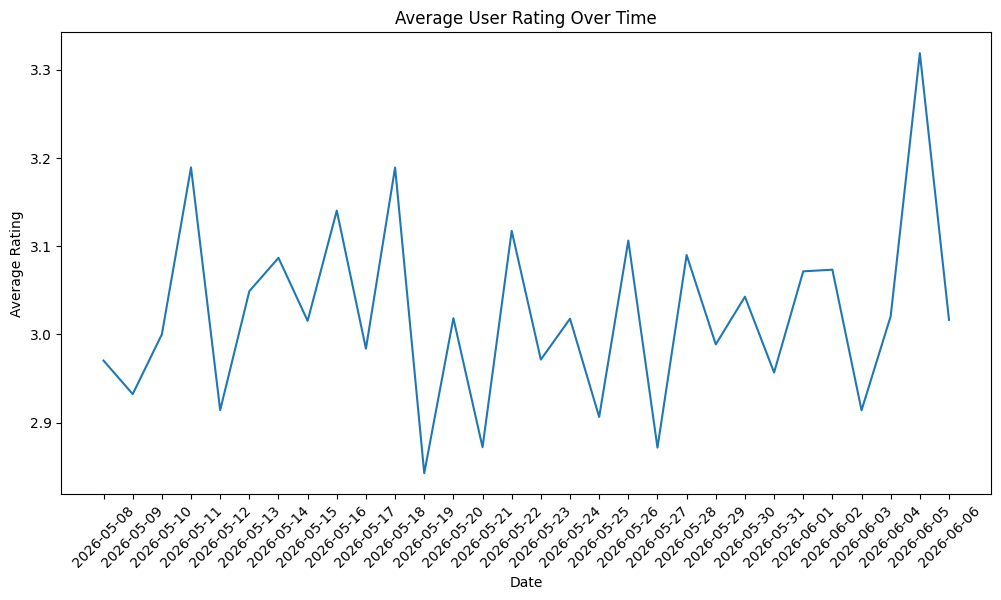

In [94]:
import matplotlib.pyplot as plt

# Create line chart
plt.figure(figsize=(12, 6))

plt.plot(
    daily_ratings["watch_date"],
    daily_ratings["user_rating"]
)

plt.title("Average User Rating Over Time")
plt.xlabel("Date")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

In [95]:
# Compare the ratings given to movies by different users using scipy.stats.pearsonr (to find users with similar tastes)
from scipy.stats import pearsonr


# Take first two users
user1 = users[0]

# User 1 ratings
user1_ratings = {
    entry["movie"]: entry["user_rating"]
    for entry in user1.watch_history #entry - the name of loop variable
}



In [96]:
#Let's find a user who has the highest number of common with user1 movies, and make sure that the number of common movies is at least 3

# Movies watched by user1
user1_movies = {
    history_entry["movie"]
    for history_entry in user1.watch_history
}
print(user1_movies)
print(len(user1_movies))

{'The Conjuring', 'Dune', 'Deadpool'}
3


In [97]:
# Best match variables
best_match = None
max_common_movies = 0

# Check all users
for user in users:

    # Skip user1
    if user == user1:
        continue

    # Movies watched by current user
    user_movies = {
        history_entry["movie"]
        for history_entry in user.watch_history
    }

    # Find common movies
    common_movies = user1_movies & user_movies

    # Update best match
    if len(common_movies) > max_common_movies:
        max_common_movies = len(common_movies)
        best_match = user
        best_common_movies = common_movies
print(best_match.name)
print(max_common_movies)
print(best_common_movies)

William Zuniga
3
{'The Conjuring', 'Dune', 'Deadpool'}


In [98]:
user2 = best_match

In [99]:
# User 2 ratings - let's do Dictionary Comprehension
user2_ratings = {
    entry["movie"]: entry["user_rating"]
    for entry in user2.watch_history
}

# find common movies using 'intersection' &
common_movies = set(user1_ratings.keys()) & set(user2_ratings.keys())

print(common_movies)
print(len(common_movies))

{'The Conjuring', 'Dune', 'Deadpool'}
3


In [100]:
print(user2_ratings.keys())

dict_keys(['Deadpool', 'Parasite', 'Dune', 'The Conjuring', 'Avengers: Endgame'])


In [101]:
user1_scores = []
user2_scores = []

for movie in common_movies:
    user1_scores.append(user1_ratings[movie])
    user2_scores.append(user2_ratings[movie])

print(user1_scores)
print(user2_scores)

[1, 4, 3]
[3, 1, 1]


In [102]:
correlation, p_value = pearsonr(
    user1_scores,
    user2_scores
)

print(correlation)
print(p_value)

-0.9449111825230683
0.2122956150096562


correlation around 0 shows that tastes of users are not correlating

In [103]:
#recommend to user1 movies from similar user (best_match)

# Movies watched by user1
user1_movies = {
    entry["movie"]
    for entry in user1.watch_history
}

# Movies watched by similar user
best_match_movies = {
    entry["movie"]
    for entry in best_match.watch_history
}

# Movies to recommend
recommended_movies = (
    best_match_movies
    - user1_movies
)

print(recommended_movies)
print(len(recommended_movies))

{'Parasite', 'Avengers: Endgame'}
2


In [104]:
print(df["user_rating"].describe())

count    5464.000000
mean        3.022145
std         1.417983
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: user_rating, dtype: float64


In [105]:
# Get recommendations for first user
recommendations = engine.recommend_movies(users[0])

recommended_genres = []
print(len(recommendations))

for movie in recommendations:

    movie_genres = movie.genre.split(", ")

    recommended_genres.extend(movie_genres)
    print(movie.title)


3
Titanic
The Notebook
Get Out


In [106]:
# Calculate frequency
recommended_genres_df = pd.DataFrame(
    {"genre": recommended_genres}
)

genre_counts = (
    recommended_genres_df["genre"]
    .value_counts()
)
print(genre_counts)

genre
Drama       2
Romance     2
Horror      1
Mystery     1
Thriller    1
Name: count, dtype: int64


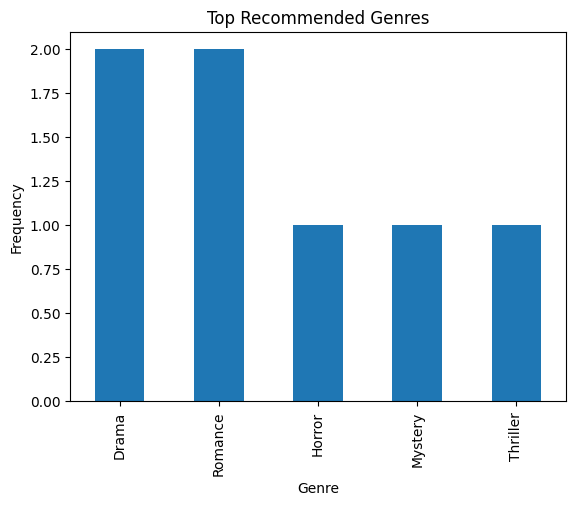

In [107]:
# Top Recommended Genres (bar chart)
import matplotlib.pyplot as plt

genre_counts.plot(
    kind="bar"
)

plt.title("Top Recommended Genres")
plt.xlabel("Genre")
plt.ylabel("Frequency")

plt.show()

In [114]:
# K-Means clustering for clustering users into groups based on their genre preferences
# create user table
user_rows = []

for user in users:

    row = {
        "name": user.name
    }

    for genre in genres:
        row[genre] = int(genre in user.preferences)

    user_rows.append(row)

users_df = pd.DataFrame(user_rows)

print(users_df.head())


               name  Action  Drama  Comedy  Sci-Fi  Thriller  Horror  Romance
0  Elizabeth Castro       0      0       0       0         0       1        1
1      Donna Stokes       0      1       0       1         0       0        0
2     Timothy Munoz       0      1       0       0         1       0        0
3        Karen West       1      0       0       1         0       0        0
4     Michael Smith       1      0       1       0         0       0        0


In [115]:
#kmeans2 - the functiona that performs k-means clustering (splitting users with similar preferences)
from scipy.cluster.vq import kmeans2

features = users_df.drop("name", axis=1) #remove Name columns, because k-means doesn't understand text, so features will be just preferences without user names

print(features.head())

   Action  Drama  Comedy  Sci-Fi  Thriller  Horror  Romance
0       0      0       0       0         0       1        1
1       0      1       0       1         0       0        0
2       0      1       0       0         1       0        0
3       1      0       0       1         0       0        0
4       1      0       1       0         0       0        0


In [122]:
features = features.astype(float) #convert. the type to float for using in k-means
print(features.dtypes)

Action      float64
Drama       float64
Comedy      float64
Sci-Fi      float64
Thriller    float64
Horror      float64
Romance     float64
dtype: object


In [123]:
# clustering
centroids, labels = kmeans2(
    features,
    3, #splitting users into 3 groups
    minit="points" #starting cluster centers (centroids)
)

In [124]:
# add cluster numbers to users
users_df["cluster"] = labels

print(users_df.head())

               name  Action  Drama  Comedy  Sci-Fi  Thriller  Horror  Romance  \
0  Elizabeth Castro       0      0       0       0         0       1        1   
1      Donna Stokes       0      1       0       1         0       0        0   
2     Timothy Munoz       0      1       0       0         1       0        0   
3        Karen West       1      0       0       1         0       0        0   
4     Michael Smith       1      0       1       0         0       0        0   

   cluster  
0        2  
1        0  
2        0  
3        1  
4        1  


In [126]:
#check cluster sizes
print(users_df["cluster"].value_counts())

cluster
0    479
1    344
2    177
Name: count, dtype: int64


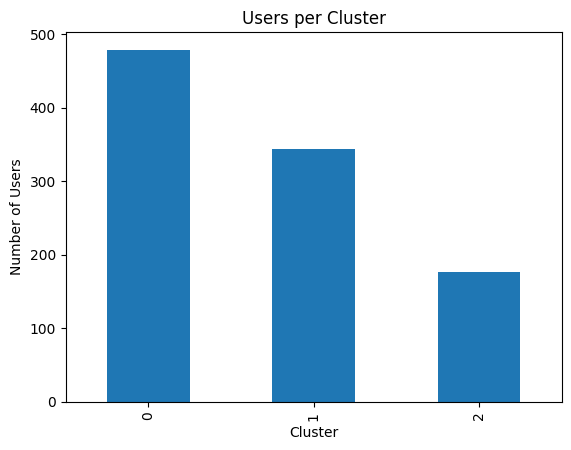

In [127]:
users_df["cluster"].value_counts().plot(kind="bar")

plt.title("Users per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Users")

plt.show()

In [129]:
cluster_profile = (
    users_df
    .drop("name", axis=1)
    .groupby("cluster")
    .mean()
)

print(cluster_profile)

           Action     Drama    Comedy    Sci-Fi  Thriller    Horror  Romance
cluster                                                                     
0        0.160752  0.486430  0.296451  0.185804  0.549061  0.321503  0.00000
1        0.563953  0.000000  0.264535  0.563953  0.000000  0.299419  0.30814
2        0.000000  0.293785  0.192090  0.000000  0.254237  0.259887  1.00000


K-Means clustering grouped users into three preference-based segments:

Cluster 0: Drama / Thriller fans
Cluster 1: Action / Sci-Fi fans
Cluster 2: Romance-oriented users

In [135]:
# recommendations based on clustering

#check cluster of user 1
user_cluster = users_df.loc[0, "cluster"]

print(user_cluster)

2


In [139]:
# find all users of the same cluster




user_cluster = users_df.loc[0, "cluster"]

cluster_user_names = (
    users_df[
        users_df["cluster"] == user_cluster
    ]["name"]
)

print(cluster_user_names.head())





0      Elizabeth Castro
5     Kathleen Ross DDS
10       Lorraine Hicks
15       Lindsay Martin
18       Matthew Brooks
Name: name, dtype: object


In [143]:
# find views of the same cluster
cluster_movies = df[
    df["user_name"].isin(cluster_user_names)
]

print(cluster_movies.head())

            user_name              movie                      genre  \
0    Elizabeth Castro               Dune  Action, Adventure, Sci-Fi   
1    Elizabeth Castro      The Conjuring  Horror, Mystery, Thriller   
2    Elizabeth Castro           Deadpool     Action, Comedy, Sci-Fi   
21  Kathleen Ross DDS  Avengers: Endgame  Action, Adventure, Sci-Fi   
22  Kathleen Ross DDS       Interstellar   Adventure, Drama, Sci-Fi   

    user_rating  watch_date  
0             4  2026-05-31  
1             1  2026-05-25  
2             3  2026-06-01  
21            4  2026-06-04  
22            2  2026-06-01  


In [144]:
#check what movies the 1st user has already watched
watched_movies = [
    entry["movie"]
    for entry in users[0].watch_history
]

print(watched_movies)

['Dune', 'The Conjuring', 'Deadpool']


In [150]:
# calculate average rating of the movies inside cluser
movie_scores = (
    cluster_movies
    .groupby("movie")["user_rating"]
    .mean()
    .sort_values(ascending=False)
)

print(movie_scores.head(10))

movie
Avengers: Endgame    3.166667
Deadpool             3.102941
Interstellar         3.074627
Dune                 3.048387
Joker                3.044118
Superbad             3.042254
The Dark Knight      3.028169
The Notebook         3.013333
Parasite             2.985075
The Conjuring        2.950820
Name: user_rating, dtype: float64


In [151]:
#remove already watched movies
recommendations = movie_scores[
    ~movie_scores.index.isin(watched_movies) #~ does NOT - leave movies that user hasn't watched yet
]

print(recommendations.head(5))

movie
Avengers: Endgame    3.166667
Interstellar         3.074627
Joker                3.044118
Superbad             3.042254
The Dark Knight      3.028169
Name: user_rating, dtype: float64
